# Normalising Flows for MNIST
## Real-NVP · PyTorch · Exact Log-Likelihood

This notebook implements a **Real-NVP normalising flow** (Dinh et al., 2017)
applied to MNIST.  Normalising flows are a third family of deep generative
models alongside VAEs and diffusion models, with distinct properties:

| Property | RBM | VAE | DDPM | **Normalising Flow** |
|:---------|:----|:----|:-----|:--------------------|
| Log-likelihood | Approx (CD) | Lower bound (ELBO) | Implicit | **Exact** |
| Latent space | Binary $h$ | Gaussian $z$ | None | Gaussian $z$ |
| Sampling | Gibbs chain | One decode | 1000 steps | **One inverse pass** |
| Encoder | Approximate | Approximate | N/A | **Exact inverse** |
| Training | Contrastive | ELBO | Noise MSE | **NLL** |

**Contents**

| § | Topic |
|:--|:------|
| 1 | Theory: change of variables, normalising flows, Real-NVP |
| 2 | Imports and helpers |
| 3 | Data preprocessing: dequantisation and logit transform |
| 4 | `ActNorm` — data-dependent normalisation layer |
| 5 | `AffineCoupling` — the Real-NVP coupling layer |
| 6 | `RealNVP` — full flow model |
| 7 | MNIST loading |
| 8 | Training |
| 9 | Generation — exact one-pass sampling |
| 10 | Analysis: BPD, temperature sampling, latent space |

## 1. Theory

### 1.1 The change-of-variables formula

A normalising flow learns an **invertible** mapping
$f_\theta: \mathcal{X}\to\mathcal{Z}$ between the data space $\mathcal{X}$
and a simple latent space $\mathcal{Z}$ (we use $p_Z = \mathcal{N}(0,\mathbf{I})$).
The change-of-variables formula gives the **exact** data log-likelihood:

$$\log p_\theta(\mathbf{x}) =
\underbrace{\log p_Z(f_\theta(\mathbf{x}))}_{\text{log prior}}
+\underbrace{\log\left|\det\frac{\partial f_\theta}{\partial \mathbf{x}}\right|}{\text{log abs-det Jacobian}}$$

Because the flow is invertible, **exact sampling** is also trivial:
sample $\mathbf{z}\sim p_Z$, then compute $\mathbf{x}=f_\theta^{-1}(\mathbf{z})$.

### 1.2 Real-NVP affine coupling layers

Computing the full Jacobian determinant naively costs $O(D^3)$.
Real-NVP makes it $O(D)$ via **affine coupling layers**:
split $\mathbf{x}=(\mathbf{x}_a,\mathbf{x}_b)$ using a binary mask $\mathbf{m}$,
then transform only $\mathbf{x}_b$ as a function of $\mathbf{x}_a$:

$$\mathbf{y}_a = \mathbf{x}_a$$

$$\mathbf{y}_b = \mathbf{x}_b \odot \exp\!\bigl(s(\mathbf{x}_a)\bigr)
               + t(\mathbf{x}_a)$$

where $s, t: \mathbb{R}^{|a|}\to\mathbb{R}^{|b|}$ are arbitrary neural networks
(the **coupling network**).  The Jacobian is lower-triangular, so its
log-determinant is just the sum of the scale log-activations:

$$\log\left|\det\frac{\partial \mathbf{y}}{\partial \mathbf{x}}\right|
= \sum_i s_i(\mathbf{x}_a)$$

**Inverse** (used for generation) is also cheap:

$$\mathbf{x}_a = \mathbf{y}_a$$

$$\mathbf{x}_b = (\mathbf{y}_b - t(\mathbf{y}_a))\odot\exp\!\bigl(-s(\mathbf{y}_a)\bigr)$$

### 1.3 ActNorm

**ActNorm** (Kingma & Dhariwal, 2018) is an invertible per-channel
affine transformation $y_i = (x_i - \mu_i)/\sigma_i$ whose parameters
$\mu_i, \sigma_i$ are **initialised from the first batch** so that
the post-ActNorm activations have zero mean and unit variance.
It acts like BatchNorm but is fully invertible and has no running-mean
statistics to update after initialisation.

### 1.4 Full architecture

```
Input x  ∈ [0,1]^784   (MNIST pixel after dequantisation)
  ↓
Logit transform: x ← logit(α + (1-2α)x),  α=0.05   → R^784
  ↓
[ActNorm]
[AffineCoupling  mask=checkerboard-0]
[AffineCoupling  mask=checkerboard-1]   ← 2 per block
[ActNorm]
[AffineCoupling  mask=checkerboard-0]
[AffineCoupling  mask=checkerboard-1]
[ActNorm]
[AffineCoupling  mask=checkerboard-0]
[AffineCoupling  mask=checkerboard-1]
[ActNorm]
[AffineCoupling  mask=checkerboard-0]
[AffineCoupling  mask=checkerboard-1]   ← 8 coupling layers total
  ↓
z  ∈ R^784   standard Gaussian prior p_Z = N(0, I)
```

### 1.5 Training objective

Maximise exact log-likelihood, equivalently minimise negative log-likelihood:

$$\mathcal{L} = -\mathbb{E}_{\mathbf{x}\sim p_{\rm data}}\!\bigl[\log p_\theta(\mathbf{x})\bigr]$$

The standard reporting metric is **bits-per-dimension (BPD)**:

$$\mathrm{BPD} = -\frac{\log_2 p_\theta(\mathbf{x})}{D},
\quad D = 784$$

Lower BPD = higher log-likelihood = better model.
State-of-the-art flows achieve $\approx 1.0$ BPD on MNIST.

---

## 2. Imports and Helpers

In [1]:
%matplotlib inline
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ── Reproducibility ───────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device         : {device}')
print(f'PyTorch version: {torch.__version__}')


# ── Image grid display ────────────────────────────────────────────────

def show_grid(images, nrow=10, title='', figsize=(12, None)):
    """
    Display images as a grid.  Accepts tensor (N,784) or (N,1,28,28).
    """
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu().numpy()
    imgs = np.asarray(images, dtype=np.float32)
    if imgs.ndim == 4:
        imgs = imgs[:, 0]
    elif imgs.ndim == 2 and imgs.shape[1] == 784:
        imgs = imgs.reshape(-1, 28, 28)
    N         = len(imgs)
    nrow      = min(nrow, N)
    nrows_fig = math.ceil(N / nrow)
    h         = figsize[1] or nrows_fig * 1.6
    fig, axes = plt.subplots(nrows_fig, nrow, figsize=(figsize[0], h),
                              squeeze=False)
    for ax in axes.flatten(): ax.axis('off')
    for i, img in enumerate(imgs):
        axes.flatten()[i].imshow(img.clip(0, 1), cmap='gray_r',
                                  vmin=0, vmax=1, interpolation='nearest')
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


print('Imports ready.')

Device         : cpu
PyTorch version: 2.3.0.post100
Imports ready.


## 3. Data Preprocessing: Dequantisation and Logit Transform

Normalising flows require **continuous** inputs (the change-of-variables
formula assumes a density, which is undefined for discrete data).
We apply two standard preprocessing steps:

**Step 1 — Dequantisation.**  MNIST pixels are integers in $\{0,\ldots,255\}$.
We add uniform noise $u\sim U[0,1]$ to each pixel before dividing by 256:

$$\tilde{x} = \frac{x_{\rm int} + u}{256}, \quad u\sim U[0,1)$$

This turns discrete values into a continuous distribution on $[0,1]$
without changing the model's log-likelihood on the original discrete data.

**Step 2 — Logit transform.**  A Gaussian prior has support on all of
$\mathbb{R}$, but $\tilde{x}\in[0,1]$.  We map $[0,1]\to\mathbb{R}$ via a
numerically-safe logit with a small boundary buffer $\alpha$:

$$x = \text{logit}(\alpha + (1-2\alpha)\tilde{x}),
\quad \alpha = 0.05$$

The log-determinant of this preprocessing step is added to the total
log-likelihood so that BPD is reported on the **original** pixel scale.

In [2]:
ALPHA = 0.05   # logit boundary buffer


def preprocess(x_01):
    """
    Map pixels in [0,1] → R via logit transform.

    1. Dequantise: x ← x + U[0,1]/255   (already done by ToTensor if needed)
       Here x_01 is already continuous in [0,1] from torchvision.
    2. Logit:      x ← logit(α + (1-2α)·x)

    Returns (z, logdet_preprocessing) where logdet_preprocessing accounts
    for the logit Jacobian — needed to report correct BPD.
    """
    # Dequantise: add tiny uniform noise to simulate true continuous distribution
    x = x_01 + torch.rand_like(x_01) / 256.0
    x = x.clamp(1e-5, 1 - 1e-5)                # safety clamp

    # Boundary-buffered logit transform
    y = ALPHA + (1.0 - 2.0 * ALPHA) * x         # rescale to (α, 1-α)
    z = torch.log(y) - torch.log(1.0 - y)        # logit

    # Log-Jacobian of the full transformation:  d(logit(y))/dx
    # = (1-2α) / (y(1-y))
    log_det = (torch.log(torch.tensor(1.0 - 2.0 * ALPHA))
               - torch.log(y) - torch.log(1.0 - y)).sum(dim=1)  # (B,)
    return z, log_det


def postprocess(z):
    """
    Invert the logit transform: z ∈ R → x ∈ [0,1].

    x = (sigmoid(z) - α) / (1 - 2α),  then clamp to [0,1]
    """
    y = torch.sigmoid(z)
    x = (y - ALPHA) / (1.0 - 2.0 * ALPHA)
    return x.clamp(0.0, 1.0)


# Verify round-trip
_x   = torch.rand(4, 784)
_z, _ld = preprocess(_x)
_xr  = postprocess(_z)
print(f'Preprocess output range: [{_z.min():.2f}, {_z.max():.2f}]')
print(f'Log-det per sample     : {_ld[:3].tolist()}')
print(f'Round-trip max error   : {(_x - _xr).abs().max():.6f}')

Preprocess output range: [-2.87, 2.94]
Log-det per sample     : [1319.3148193359375, 1300.1978759765625, 1284.796142578125]
Round-trip max error   : 0.003903


## 4. ActNorm — Invertible Normalisation Layer

**ActNorm** initialises scale and bias from the **first training batch**
so that each dimension has zero mean and unit variance after the layer.
Subsequent forward and inverse passes use these fixed learned parameters.

Forward:  $y_i = (x_i - \mu_i) / \sigma_i$

Inverse:  $x_i = y_i \cdot \sigma_i + \mu_i$

Log-det:  $\log|\det J| = -\sum_i \log \sigma_i = \sum_i \log(1/\sigma_i)$

This is equivalent to a learnable per-dimension normalisation,
but unlike BatchNorm it is **fully invertible** and tracks no running
statistics beyond the initialised $\mu$ and $\sigma$.

In [3]:
class ActNorm(nn.Module):
    """
    Activation Normalisation (Kingma & Dhariwal, 2018).

    Learnable per-dimension affine transformation:
        forward : y = (x - μ) / σ
        inverse : x = y · σ + μ
        log_det : -sum(log σ)  per sample

    Parameters μ and log σ are initialised on the first batch so that
    each dimension of the output has zero mean and unit variance.
    """

    def __init__(self, dim):
        super().__init__()
        self.dim       = dim
        self.loc       = nn.Parameter(torch.zeros(dim))   # μ
        self.log_scale = nn.Parameter(torch.zeros(dim))   # log σ
        self.register_buffer('initialized', torch.tensor(False))

    def _initialize(self, x):
        """Data-dependent initialisation from the first batch."""
        with torch.no_grad():
            mean = x.mean(dim=0)           # (dim,)
            std  = x.std(dim=0) + 1e-6    # (dim,)
            self.loc.data.copy_(mean)
            self.log_scale.data.copy_(torch.log(std))
            self.initialized.fill_(True)

    def forward(self, x):
        """
        x       : (B, dim)
        Returns (y, log_det) where log_det : (B,) is the same for all samples.
        """
        if not self.initialized:
            self._initialize(x)
        y       = (x - self.loc) * torch.exp(-self.log_scale)
        log_det = -self.log_scale.sum()                   # scalar
        return y, log_det.expand(x.size(0))               # broadcast to (B,)

    def inverse(self, y):
        """y : (B, dim)  →  x : (B, dim)"""
        return y * torch.exp(self.log_scale) + self.loc


# Quick test
_an = ActNorm(8)
_x  = torch.randn(16, 8) * 3 + 2   # mean≈2, std≈3
_y, _ld = _an(_x)
print(f'ActNorm test:')
print(f'  Input  mean={_x.mean():.3f}  std={_x.std():.3f}')
print(f'  Output mean={_y.mean():.3f}  std={_y.std():.3f}  (should be ≈0, ≈1)')
print(f'  log_det shape: {_ld.shape}')
_xr = _an.inverse(_y)
print(f'  Round-trip error: {(_x-_xr).abs().max():.2e}')

ActNorm test:
  Input  mean=2.165  std=2.989
  Output mean=0.000  std=0.972  (should be ≈0, ≈1)
  log_det shape: torch.Size([16])
  Round-trip error: 4.77e-07


## 5. Affine Coupling Layer

The coupling layer splits dimensions using a binary **mask** $\mathbf{m}\in\{0,1\}^D$:

- **Masked dimensions** ($m_i=1$, the *active* part $\mathbf{x}_a$): pass through unchanged
- **Unmasked dimensions** ($m_i=0$, the *passive* part $\mathbf{x}_b$): transformed by
  a scale-translation function of $\mathbf{x}_a$

We use **checkerboard masks** on the $28\times28$ grid — alternating 0/1
like a chess board, then flattened to length 784.  Alternating masks between
layers ensures every dimension is transformed in every other layer.

The **coupling network** $\mathrm{NN}(\mathbf{x}_a)\to(s,t)$ is a
3-layer MLP with SiLU activations.  The scale output is tanh-scaled
to $[-2, 2]$ to prevent the exponential $\exp(s)$ from becoming too
large or too small (a standard stabilisation trick).

**Forward** (encode $x\to z$):
$$\mathbf{y}_a = \mathbf{x}_a$$
$$\mathbf{y}_b = \mathbf{x}_b \odot \exp(s(\mathbf{x}_a)) + t(\mathbf{x}_a)$$
$$\log|\det J| = \sum_i s_i(\mathbf{x}_a)$$

**Inverse** (generate $z\to x$):
$$\mathbf{x}_a = \mathbf{y}_a$$
$$\mathbf{x}_b = (\mathbf{y}_b - t(\mathbf{y}_a))\odot\exp(-s(\mathbf{y}_a))$$

In [4]:
def checkerboard_mask(dim, parity, device='cpu'):
    """
    Checkerboard mask for 28×28 images flattened to (dim,).

    parity=0: pixel (i,j) is masked iff (i+j) is even
    parity=1: complement of parity=0

    Returns binary mask tensor of shape (dim,) on device.
    """
    h = w = int(round(dim ** 0.5))   # 28 for MNIST
    assert h * w == dim, f'dim={dim} is not a perfect square'
    rows = torch.arange(h)[:, None].expand(h, w)   # (28,28)
    cols = torch.arange(w)[None, :].expand(h, w)
    mask = ((rows + cols) % 2 == parity).float()    # (28,28)
    return mask.view(-1).to(device)                 # (784,)


class CouplingNetwork(nn.Module):
    """
    MLP that maps masked dimensions → (scale s, translation t).
    Output scale is bounded to [-scale_bound, scale_bound] via tanh.
    """
    def __init__(self, in_dim, out_dim, hidden=256, scale_bound=2.0):
        super().__init__()
        self.scale_bound = scale_bound
        self.net = nn.Sequential(
            nn.Linear(in_dim,  hidden), nn.SiLU(),
            nn.Linear(hidden,  hidden), nn.SiLU(),
            nn.Linear(hidden,  hidden), nn.SiLU(),
            nn.Linear(hidden, out_dim * 2),   # outputs s and t concatenated
        )
        # Initialise last layer to zero → identity transform at start
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x_masked):
        """
        x_masked : (B, n_masked)
        Returns  s : (B, n_unmasked),  t : (B, n_unmasked)
        """
        st  = self.net(x_masked)                         # (B, 2*out_dim)
        s, t = st.chunk(2, dim=1)                        # each (B, out_dim)
        s    = torch.tanh(s) * self.scale_bound          # bound scale to [-2,2]
        return s, t


class AffineCoupling(nn.Module):
    """
    Real-NVP affine coupling layer.

    Uses a checkerboard mask to split dimensions:
        masked   (m=1): passed through unchanged (active part  xₐ)
        unmasked (m=0): transformed by NN(xₐ)   (passive part x_b)

    Forward  (encode):
        yₐ = xₐ
        y_b = x_b ⊙ exp(s(xₐ)) + t(xₐ)
        log|det J| = Σ s(xₐ)   (sum over unmasked dims)

    Inverse  (decode / generate):
        xₐ = yₐ
        x_b = (y_b - t(yₐ)) ⊙ exp(-s(yₐ))
    """

    def __init__(self, dim, mask_parity, hidden=256):
        super().__init__()
        self.dim    = dim
        self.parity = mask_parity

        # Build the mask; will be moved to device lazily
        mask = checkerboard_mask(dim, mask_parity)
        self.register_buffer('mask', mask)   # (dim,)

        n_masked   = int(mask.sum().item())          # active dims
        n_unmasked = dim - n_masked                  # passive dims

        self.net = CouplingNetwork(n_masked, n_unmasked, hidden=hidden)

    def forward(self, x):
        """
        x   : (B, dim)
        Returns (y, log_det) where log_det : (B,)
        """
        m       = self.mask                             # (dim,)
        x_a     = x[:, m == 1]                         # (B, n_masked)
        x_b     = x[:, m == 0]                         # (B, n_unmasked)

        s, t    = self.net(x_a)                         # each (B, n_unmasked)
        y_b     = x_b * torch.exp(s) + t               # transform passive dims

        # Reconstruct full output (maintain original dimension order)
        y = x.clone()
        y[:, m == 0] = y_b

        log_det = s.sum(dim=1)                         # (B,)
        return y, log_det

    def inverse(self, y):
        """
        y   : (B, dim)
        Returns x : (B, dim)
        """
        m    = self.mask
        y_a  = y[:, m == 1]
        y_b  = y[:, m == 0]

        s, t = self.net(y_a)
        x_b  = (y_b - t) * torch.exp(-s)

        x = y.clone()
        x[:, m == 0] = x_b
        return x


# Shape and round-trip test
_ac = AffineCoupling(dim=784, mask_parity=0, hidden=64)
_x  = torch.randn(4, 784)
_y, _ld = _ac(_x)
_xr     = _ac.inverse(_y)
print(f'AffineCoupling test:')
print(f'  Input shape : {_x.shape}')
print(f'  Output shape: {_y.shape}')
print(f'  log_det     : {_ld.shape}')
print(f'  Round-trip max error: {(_x-_xr).abs().max():.2e}  (should be ≈0)')

AffineCoupling test:
  Input shape : torch.Size([4, 784])
  Output shape: torch.Size([4, 784])
  log_det     : torch.Size([4])
  Round-trip max error: 0.00e+00  (should be ≈0)


## 6. `RealNVP` — Full Normalising Flow Model

The full model is a sequence of **ActNorm** and **AffineCoupling** layers.
We use 4 blocks, each consisting of:
- 1 `ActNorm`
- 1 `AffineCoupling` with parity 0
- 1 `AffineCoupling` with parity 1

This gives 8 coupling layers total.  Alternating parities ensures every
dimension is transformed in adjacent layers.

**Forward pass** (encode): compute $z = f(x)$ and accumulate the total
log-determinant from all layers plus the preprocessing Jacobian.

**Log-likelihood** per sample:

$$\log p_\theta(x) = \underbrace{\log p_Z(z)}_{-\frac{1}{2}\|z\|^2
- \frac{D}{2}\log 2\pi}
+\underbrace{\sum_{\ell}\log|\det J_\ell|}_{\text{coupling + actnorm log-dets}}
+\underbrace{\log|\det J_{\rm preproc}|}_{\text{logit Jacobian}}$$

**Inverse pass** (generate): apply layers in reverse to map $z\to x$.

In [5]:
class RealNVP(nn.Module):
    """
    Real-NVP normalising flow for flattened 28×28 images.

    Architecture: N_BLOCKS × (ActNorm + Coupling(parity=0) + Coupling(parity=1))

    Forward  (encode):  x → z, returns (z, log_det_total)
    Inverse  (decode):  z → x  (for generation)
    log_prob(x):        exact log p(x) = log p_Z(z) + log_det_total + logit_logdet
    """

    def __init__(self, dim=784, n_blocks=4, hidden=256):
        super().__init__()
        self.dim = dim

        # Build layers: each block = ActNorm + 2 coupling layers
        layers = []
        for _ in range(n_blocks):
            layers.append(ActNorm(dim))
            layers.append(AffineCoupling(dim, mask_parity=0, hidden=hidden))
            layers.append(AffineCoupling(dim, mask_parity=1, hidden=hidden))
        self.layers = nn.ModuleList(layers)

        n_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'RealNVP: dim={dim}, {n_blocks} blocks '
              f'({len(layers)} layers), {n_params:,} parameters')

    # ── Forward: x → z  (encode) ──────────────────────────────────────

    def forward(self, x):
        """
        x : (B, dim)  in logit-transformed space (output of preprocess)
        Returns (z, log_det) where log_det (B,) is the total log|det J|
        summed over all layers.
        """
        log_det = torch.zeros(x.size(0), device=x.device)
        z = x
        for layer in self.layers:
            if isinstance(layer, ActNorm):
                z, ld = layer(z)
            else:  # AffineCoupling
                z, ld = layer(z)
            log_det = log_det + ld
        return z, log_det

    # ── Inverse: z → x  (decode / generate) ───────────────────────────

    @torch.no_grad()
    def inverse(self, z):
        """
        z : (B, dim)  latent code sampled from N(0, I)
        Returns x in logit-transformed space; postprocess() converts to [0,1].
        """
        x = z
        for layer in reversed(self.layers):
            if isinstance(layer, ActNorm):
                x = layer.inverse(x)
            else:
                x = layer.inverse(x)
        return x

    # ── Exact log-likelihood ───────────────────────────────────────────

    def log_prob(self, x_01):
        """
        Compute exact log p(x) for a batch of raw [0,1] pixel images.

        log p(x) = log p_Z(z)  +  log|det J_flow|  +  log|det J_preproc|

        Parameters
        ----------
        x_01 : (B, dim)  raw pixel values in [0, 1]

        Returns
        -------
        log_p : (B,)  log-likelihood per sample
        """
        # Preprocessing: dequantise + logit
        z_pre, ld_pre = preprocess(x_01)           # z_pre in R^dim, ld_pre (B,)

        # Flow: z_pre → z
        z, ld_flow = self.forward(z_pre)            # z in R^dim, ld_flow (B,)

        # Standard Gaussian log-probability:  -0.5||z||^2 - D/2 * log(2π)
        log_pz = (-0.5 * z.pow(2).sum(dim=1)
                  - 0.5 * self.dim * math.log(2 * math.pi))

        return log_pz + ld_flow + ld_pre            # (B,)

    # ── Bits per dimension ─────────────────────────────────────────────

    def bpd(self, x_01):
        """
        Bits per dimension (BPD) = -log2(p(x)) / D.
        Lower is better.  State-of-art flows achieve ~1.0 BPD on MNIST.
        """
        return (-self.log_prob(x_01) / (self.dim * math.log(2))).mean()


# Instantiate
N_BLOCKS = 4
HIDDEN   = 256
model    = RealNVP(dim=784, n_blocks=N_BLOCKS, hidden=HIDDEN).to(device)

# Shape test
_x  = torch.rand(4, 784, device=device)
_lp = model.log_prob(_x)
print(f'log_prob shape: {_lp.shape}  (expected (4,))')
print(f'Initial BPD (random model): {model.bpd(_x):.2f}  (should be large)')

# Round-trip test through the flow
with torch.no_grad():
    _xp, _ = preprocess(_x)
    _z, _  = model(_xp)
    _xp_r  = model.inverse(_z)
    _x_r   = postprocess(_xp_r)
print(f'Flow round-trip max error: {(_xp-_xp_r).abs().max():.2e}')

RealNVP: dim=784, 4 blocks (12 layers), 3,475,712 parameters
log_prob shape: torch.Size([4])  (expected (4,))
Initial BPD (random model): -0.33  (should be large)
Flow round-trip max error: 4.77e-07


## 7. MNIST Loading

We use `torchvision.datasets.MNIST` with `ToTensor()` only (pixels in
$[0,1]$).  The dequantisation and logit transform are applied inside
`log_prob` at training time, which ensures the dequantisation noise
is freshly sampled every epoch (important for training a good density).

For generation we apply `postprocess` to map the flow output back to
$[0,1]$ pixel values.

Train: 60,000  Test: 10,000
Batches per epoch: 235


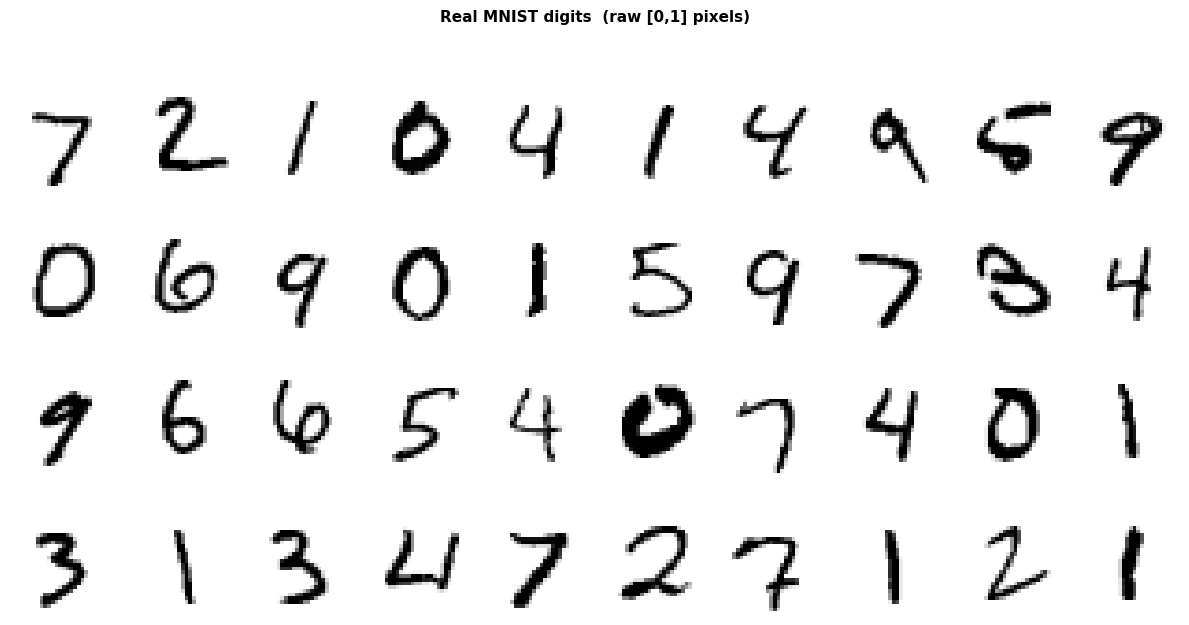

In [6]:
BATCH_SIZE = 256

transform  = transforms.Compose([transforms.ToTensor()])

train_ds   = datasets.MNIST('./data', train=True,
                             download=True, transform=transform)
test_ds    = datasets.MNIST('./data', train=False,
                             download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds):,}  Test: {len(test_ds):,}')
print(f'Batches per epoch: {len(train_loader)}')

# Show some real digits
x_real, y_real = next(iter(test_loader))
show_grid(x_real[:40].view(-1, 784), nrow=10,
          title='Real MNIST digits  (raw [0,1] pixels)')

## 8. Training

We minimise the **negative log-likelihood** (NLL), which is equivalent
to maximising the exact ELBO — but for flows this *is* the exact
log-likelihood, not a lower bound.

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \log p_\theta(x_i)$$

Reported in **bits per dimension** (BPD) = $\mathcal{L}/(D\ln 2)$.

**Training tips for flows:**
- `clip_grad_norm_` is critical — coupling layer gradients can spike
  when the scale $\exp(s)$ becomes large early in training
- Cosine annealing helps converge to a lower NLL
- A **warm-up** phase for the first few epochs prevents ActNorm from
  receiving gradients before it has seen enough data to initialise well

In [ ]:
EPOCHS   = 25
LR       = 3e-4
WARMUP   = 2      # linear LR warmup epochs

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    return 0.5 * (1 + math.cos(math.pi * (epoch - WARMUP) / (EPOCHS - WARMUP)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

history   = {'train_bpd': [], 'val_bpd': []}
t0        = time.time()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Training Real-NVP on MNIST')
print(f'  {N_BLOCKS} blocks, hidden={HIDDEN}, {n_params:,} params')
print(f'  epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LR}')
print(f'  device={device}')
print()

for ep in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────
    model.train()
    t_ep    = time.time()
    ep_nll  = 0.0
    n_bat   = 0

    for x_batch, _ in train_loader:
        x_batch = x_batch.view(-1, 784).to(device)   # (B, 784)

        # Exact NLL = -mean log_prob
        log_p = model.log_prob(x_batch)               # (B,)
        loss  = -log_p.mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        ep_nll += loss.item()
        n_bat  += 1

    scheduler.step()
    train_bpd = ep_nll / n_bat / math.log(2)   # convert nats → bits, per dim

    # ── Validation ────────────────────────────────────────────────────
    model.eval()
    val_nll = 0.0; n_val = 0
    with torch.no_grad():
        for xv, _ in test_loader:
            xv      = xv.view(-1, 784).to(device)
            log_p_v = model.log_prob(xv)
            val_nll += (-log_p_v.mean()).item()
            n_val   += 1
    val_bpd = val_nll / n_val / math.log(2)

    history['train_bpd'].append(train_bpd)
    history['val_bpd'].append(val_bpd)

    print(f'  Epoch {ep:3d}/{EPOCHS}  '
          f'train BPD={train_bpd:.4f}  '
          f'val BPD={val_bpd:.4f}  '
          f'lr={scheduler.get_last_lr()[0]:.2e}  '
          f'({time.time()-t_ep:.1f}s)')

print(f'\nTotal training time: {time.time()-t0:.1f}s')
print(f'Final validation BPD: {history["val_bpd"][-1]:.4f}')

Training Real-NVP on MNIST
  4 blocks, hidden=256, 3,475,712 params
  epochs=25, batch=256, lr=0.0003
  device=cpu



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, history['train_bpd'], 'b-o', ms=4, lw=2, label='Train')
axes[0].plot(ep, history['val_bpd'],   'r-s', ms=4, lw=2, label='Val')
axes[0].set(xlabel='Epoch', ylabel='Bits per dimension (↓ better)',
            title='Real-NVP training — BPD')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['train_bpd'], 'b-o', ms=4, lw=2, label='Train')
axes[1].plot(ep, history['val_bpd'],   'r-s', ms=4, lw=2, label='Val')
axes[1].set(xlabel='Epoch', ylabel='BPD (zoomed)',
            title='Training curve (last 80%)',
            xlim=(EPOCHS*0.2, EPOCHS))
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Real-NVP Normalising Flow on MNIST', fontsize=12,
             fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Generation — Exact One-Pass Sampling

Because the flow is invertible, generating a new image requires a
**single forward pass** through the inverse network:

1. Sample $z\sim\mathcal{N}(0,\sigma^2\mathbf{I})$ (temperature $\sigma$)
2. Apply layers in reverse: $\hat{x} = f_\theta^{-1}(z)$
3. Invert the logit preprocessing: $x = \text{sigmoid}(\hat{x})$

**Temperature** $\sigma$ controls diversity vs quality:
- $\sigma=1.0$: samples from the exact learned distribution
- $\sigma<1.0$: samples from a sharper, more 'typical' region of the distribution
  — images tend to be cleaner and more digit-like
- $\sigma>1.0$: more diverse but noisier samples

This is a key advantage of flows: **exact** generation in one pass,
compared to 1000 steps for DDPM or Gibbs sampling for RBMs.

In [ ]:
@torch.no_grad()
def sample(mdl, n_samples=80, temperature=0.8):
    """
    Generate images from the normalising flow.

    1. z ~ N(0, temperature² I)   — sample from temperature-scaled prior
    2. x_logit = f⁻¹(z)           — inverse flow
    3. x = postprocess(x_logit)   — invert logit transform → [0,1]

    Parameters
    ----------
    temperature : float
        σ of the sampling Gaussian.  <1 = sharper, >1 = more diverse.
    """
    mdl.eval()
    z        = torch.randn(n_samples, mdl.dim, device=device) * temperature
    x_logit  = mdl.inverse(z)
    return postprocess(x_logit)


# Generate at three temperatures
for temp in [1.0, 0.8, 0.6]:
    x_gen = sample(model, n_samples=80, temperature=temp)
    show_grid(x_gen, nrow=10,
              title=f'Generated MNIST digits — Real-NVP  (T={temp})')

## 10. Analysis

Four diagnostics that are unique to (or especially natural for) normalising flows:

1. **Per-class BPD** — because log-likelihood is exact, we can measure
   which digit classes the model finds easier or harder
2. **Reconstructions** — encode $x\to z$ then decode $z\to \hat x$;
   because the flow is exact, $\hat x = x$ (round-trip error ≈ 0)
3. **Latent space interpolation** — linearly interpolate between the
   latent codes of two images; decode each point
4. **Temperature sweep** — show how sample quality changes with $\sigma$

In [ ]:
# ── 1. Per-class bits-per-dimension on the test set ──────────────────
model.eval()
class_bpd = {d: [] for d in range(10)}

with torch.no_grad():
    for x_batch, labels in test_loader:
        x_batch = x_batch.view(-1, 784).to(device)
        log_p   = model.log_prob(x_batch)          # (B,)
        bpd_per = (-log_p / (784 * math.log(2))).cpu()  # (B,)
        for d in range(10):
            mask = (labels == d)
            if mask.any():
                class_bpd[d].extend(bpd_per[mask].tolist())

print('Per-class BPD on test set (lower = better):')
print(f'  {"Digit":>6s}  {"Mean BPD":>9s}  {"Std":>7s}  {"N":>6s}')
print('  ' + '-'*32)
bpd_means = []
for d in range(10):
    vals = class_bpd[d]
    m, s = np.mean(vals), np.std(vals)
    bpd_means.append(m)
    print(f'  {d:>6d}  {m:>9.4f}  {s:>7.4f}  {len(vals):>6d}')
print(f'  {"Overall":>6s}  {np.mean(bpd_means):>9.4f}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(10), bpd_means, color='steelblue', alpha=0.8)
ax.axhline(np.mean(bpd_means), color='firebrick', ls='--',
           lw=1.5, label=f'Mean = {np.mean(bpd_means):.4f}')
ax.set(xlabel='Digit class', ylabel='Mean BPD (test set)',
       title='Real-NVP: per-class bits-per-dimension')
ax.set_xticks(range(10))
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

In [ ]:
# ── 2. Exact reconstructions (encode → decode) ───────────────────────
# Flows are perfectly invertible: the reconstruction MUST equal the input.
# This is a sanity check — any error > 1e-4 indicates a numerical issue.
x_test_batch = x_real[:20].view(-1, 784).to(device)

with torch.no_grad():
    z_encoded, _  = model(preprocess(x_test_batch)[0])  # encode
    x_decoded     = postprocess(model.inverse(z_encoded))  # decode

err = (x_test_batch - x_decoded).abs().max().item()
print(f'Max reconstruction error: {err:.2e}  (flow is exact: should be ≈0)')

fig, axes = plt.subplots(2, 10, figsize=(14, 3.5), squeeze=False)
for j in range(10):
    axes[0,j].imshow(x_test_batch[j].cpu().reshape(28,28),
                     cmap='gray_r', vmin=0, vmax=1)
    axes[0,j].axis('off')
    axes[1,j].imshow(x_decoded[j].cpu().reshape(28,28),
                     cmap='gray_r', vmin=0, vmax=1)
    axes[1,j].axis('off')
axes[0,0].set_ylabel('Input', fontsize=9)
axes[1,0].set_ylabel('Decoded', fontsize=9)
fig.suptitle('Flow encode→decode: reconstruction is exact by construction',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── 3. Latent-space interpolation ────────────────────────────────────
# Because the flow maps to a Gaussian, interpolation in z-space is
# semantically meaningful — unlike raw pixel interpolation.
pairs   = [(0, 1), (3, 8), (4, 9)]
n_steps = 10

fig, axes = plt.subplots(len(pairs), n_steps,
                          figsize=(14, len(pairs)*1.7),
                          squeeze=False)

model.eval()
with torch.no_grad():
    for row, (d1, d2) in enumerate(pairs):
        # Pick one example of each digit from the test set
        idx1 = (y_real == d1).nonzero(as_tuple=True)[0][0]
        idx2 = (y_real == d2).nonzero(as_tuple=True)[0][0]
        x1   = x_real[idx1].view(1, 784).to(device)
        x2   = x_real[idx2].view(1, 784).to(device)

        # Encode both to latent space (exact inversion)
        z1, _ = model(preprocess(x1)[0])
        z2, _ = model(preprocess(x2)[0])

        for col, t in enumerate(torch.linspace(0, 1, n_steps)):
            z_interp = (1 - t) * z1 + t * z2          # linear interpolation
            x_interp = postprocess(model.inverse(z_interp))
            axes[row, col].imshow(
                x_interp[0].cpu().reshape(28, 28),
                cmap='gray_r', vmin=0, vmax=1)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(f'{d1}→{d2}', fontsize=8,
                                rotation=0, labelpad=24, va='center')

fig.suptitle('Latent-space interpolation between digit pairs  (Real-NVP)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── 4. Temperature sweep ──────────────────────────────────────────────
# Show generated samples at a range of temperatures in one grid.
temperatures = [1.2, 1.0, 0.8, 0.7, 0.6]
n_per_row    = 8

fig, axes = plt.subplots(len(temperatures), n_per_row,
                          figsize=(n_per_row*1.6, len(temperatures)*1.8),
                          squeeze=False)
model.eval()
with torch.no_grad():
    for row, temp in enumerate(temperatures):
        imgs = sample(model, n_samples=n_per_row, temperature=temp)
        for col in range(n_per_row):
            axes[row, col].imshow(
                imgs[col].cpu().reshape(28, 28),
                cmap='gray_r', vmin=0, vmax=1)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(f'T={temp}', fontsize=9,
                                rotation=0, labelpad=30, va='center')

fig.suptitle('Temperature sweep: σ=1.2 (diverse) → σ=0.6 (sharp)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

### Architecture

| Component | Details |
|:----------|:--------|
| **Flow type** | Real-NVP (Dinh et al., 2017) |
| **Preprocessing** | Dequantisation + logit transform (α=0.05) |
| **Layers** | 4 blocks × (ActNorm + Coupling(p=0) + Coupling(p=1)) |
| **Coupling network** | 3-layer MLP, width 256, SiLU, tanh-bounded scale |
| **Masks** | Checkerboard (28×28 grid, flattened) |
| **Training** | NLL with Adam + cosine LR + warmup, grad clip 5.0 |
| **Metric** | Bits per dimension (BPD) |

### Key properties of normalising flows

| Property | Details |
|:---------|:--------|
| **Exact log-likelihood** | $\log p(x)$ has no approximation error |
| **Exact generation** | One inverse pass through the network |
| **Exact reconstruction** | Encode then decode = identity (by construction) |
| **Latent space** | Gaussian; interpolation is semantically meaningful |
| **Temperature control** | Scale $z$ at sampling time to trade diversity vs quality |

### Comparison with all course generative models

| Model | Framework | Log-$p(x)$ | Sampling | Latent | This course |
|:------|:----------|:-----------|:---------|:-------|:------------|
| **RBM** | NumPy | Approximate (CD) | Gibbs chain | Binary $h$ | `week11_rbm.ipynb` |
| **VAE** | NumPy | Lower bound (ELBO) | One decode | Gaussian $z$ | `vae_numpy.ipynb` |
| **DDPM** | NumPy | Implicit | 1000 steps | None | `diffusion_mnist.ipynb` (v1) |
| **DDPM** | PyTorch | Implicit | 1000 steps | None | `diffusion_mnist.ipynb` (v2) |
| **Real-NVP** | PyTorch | **Exact** | **One inverse pass** | Gaussian $z$ | *this notebook* |